<a href="https://colab.research.google.com/github/farrelrassya/ensemble-methods-machine-learning/blob/main/ch01_ensemble_methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Ensemble Methods -- Hype or Hallelujah?

*Companion notebook to Kunapuli, **Ensemble Methods for Machine Learning** (Manning, 2023).*

**What this chapter delivers**

- A **rigorous definition** of an ensemble and the formal aggregation rule $f_{\text{ens}}(\mathbf{x}) = \frac{1}{K}\sum_{k=1}^{K} f_k(\mathbf{x})$.
- The **bias-variance decomposition** with a complete derivation, so we understand mathematically *why* averaging helps.
- A **hands-on validation-curve study** of two single learners (decision trees and SVR) that exposes the over/underfit dynamics in real numbers.
- Our **first ensemble**: six diverse regressors averaged on the Friedman-1 problem -- with an honest analysis of when the average beats the best single learner and when it does not.
- A **taxonomy** of ensemble families that maps every remaining chapter of the book.

**Notation we will use throughout**

Symbol | Meaning
--- | ---
$\mathbf{x} \in \mathbb{R}^p$ | feature vector ($p$ features)
$y \in \mathbb{R}$ | target (regression) or $y \in \{0,1\}$ (classification)
$f^\star(\mathbf{x})$ | the *true* underlying function we want to recover
$\hat{f}(\mathbf{x})$ | a single learned model
$f_k(\mathbf{x})$ | the $k$-th base learner in an ensemble
$f_{\text{ens}}(\mathbf{x})$ | the meta-estimator (the ensemble's prediction)
$K$ | number of base learners
$\mathcal{D}$ | a training set drawn i.i.d. from some distribution

---

## 1.1 Ensemble Methods: The Wisdom of Crowds

Picture the lead data scientist on a Netflix Prize team in 2006. Her single best model -- CineMatch -- is already very good. Yet thousands of competing teams keep beating it by **combining many different models**. By the end of the contest, the winning submission was not one clever algorithm; it was a *meta-estimator* that blended dozens of models from merged teams. That single observation -- *aggregation beats the best component* -- is the empirical engine of this entire book.

### 1.1.1 The Dr. Randy Forrest analogy (intuition first)

Think of medical diagnosis at a teaching hospital. Every new patient is examined by **six residents**, each trained in a different specialty (cardiology, pulmonology, neurology, oncology, internal medicine, radiology). Each resident produces an independent verdict -- *cancer* or *no cancer* -- and the attending physician, Dr. Randy Forrest, takes the **majority vote**.

Why does this beat any one resident's opinion? Two reasons:

1. **Ensemble diversity.** The residents draw on different cases, different textbooks, different reasoning patterns. The probability that all six err on the same patient in the same way is much smaller than the probability of any one of them erring alone.
2. **Model aggregation.** Independent errors cancel when you average (regression) or vote (classification). The signal -- the part of the prediction that tracks the true diagnosis -- *adds up*. The noise -- the part that does not -- *averages out*.

### 1.1.2 Formal definition

An **ensemble method** is any learning algorithm that

- trains $K \geq 2$ **base estimators** $f_1, f_2, \dots, f_K$ on the same target $y$, possibly with varied data, features, or hyperparameters, and
- combines their predictions through an **aggregation function** $g$ to produce a **meta-estimator**

$$
f_{\text{ens}}(\mathbf{x}) \;=\; g\bigl(f_1(\mathbf{x}),\, f_2(\mathbf{x}),\, \dots,\, f_K(\mathbf{x})\bigr).
$$

For regression the simplest choice of $g$ is the arithmetic mean,

$$
\boxed{\;f_{\text{ens}}(\mathbf{x}) \;=\; \frac{1}{K} \sum_{k=1}^{K} f_k(\mathbf{x})\;}
$$

For classification it is the (weighted) majority vote,

$$
f_{\text{ens}}(\mathbf{x}) \;=\; \arg\max_{c \in \mathcal{C}} \sum_{k=1}^{K} w_k \,\mathbb{1}\!\left[f_k(\mathbf{x}) = c\right], \qquad \sum_{k} w_k = 1.
$$

The rest of the book is essentially a tour of clever choices for $g$, for the way the $f_k$ are produced, and for the order in which they are trained.

## 1.2 Why You Should Care About Ensemble Learning

Three pieces of empirical evidence.

1. **Netflix Prize, 2009.** A 10.06% RMSE improvement over CineMatch was awarded the $1M prize. Post-mortem analyses showed that almost the entire lift came from blending models, not from any individual breakthrough.
2. **Kaggle, 2015.** Anthony Goldbloom (Kaggle's co-founder) reported that the three most-used algorithms on **structured / tabular** competitions were **XGBoost**, **Random Forest**, and **Gradient Boosting Machines** -- all ensembles.
3. **Olson et al., 2018.** A benchmark on 165 tabular classification datasets found that tree-based ensembles (in particular gradient boosting and random forests) topped the ranking on a clear majority of tasks.

**Structured vs. unstructured data.** This book focuses on **tabular** problems (CSVs with $10$-$500$ features), the regime where ensembles still dominate. Deep neural networks tend to win on images, audio, and free text -- domains where the data already encodes spatial or sequential structure that a tree cannot exploit.

**A line you can use with stakeholders.** *"Individually our six models score around $76\%$ on $R^2$. Averaging them lifts $R^2$ to $82\%$, and -- more importantly -- collapses run-to-run variance, so the system behaves more predictably in production."* That second clause is often worth more than the first.

---

## 1.3 Notebook Setup

Run this cell first. On Google Colab the `pip install` line is a no-op since these libraries are pre-installed; we keep it so the notebook is self-contained when run elsewhere.

In [ ]:
# === CHAPTER 1 SETUP CELL ===
# !pip install -q scikit-learn matplotlib seaborn numpy pandas

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_friedman1
from sklearn.model_selection import ShuffleSplit, validation_curve, train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8')

print('Setup complete.')

Setup complete.


The setup confirms the imports succeeded. We pin `random_state=23` everywhere downstream so that **every number printed in this notebook is reproducible** -- a non-negotiable requirement for any teaching material that ties prose to outputs.

## 1.4 Why Single Models Plateau: The Bias-Variance Tradeoff

Every supervised model has to navigate the same fundamental tension: *fit the training data well* versus *generalise to unseen data*. The mathematical statement of this tension is the **bias-variance decomposition**, and ensembles exist almost entirely to attack one half of it.

### 1.4.1 The decomposition (full derivation)

Assume the data-generating process is

$$
y \;=\; f^\star(\mathbf{x}) \;+\; \varepsilon, \qquad \mathbb{E}[\varepsilon]=0,\quad \mathrm{Var}(\varepsilon)=\sigma^2,
$$

so $f^\star$ is the *true* regression function and $\varepsilon$ is irreducible label noise. We train a model $\hat{f}$ on a random training set $\mathcal{D}$. The *expected* squared error at a fixed test point $\mathbf{x}_0$, taken over both the training set and the noise, is

$$
\mathbb{E}_{\mathcal{D},\,\varepsilon}\!\left[(y_0 - \hat{f}_{\mathcal{D}}(\mathbf{x}_0))^2\right].
$$

Insert and subtract the mean prediction $\bar{f}(\mathbf{x}_0) := \mathbb{E}_{\mathcal{D}}[\hat{f}_{\mathcal{D}}(\mathbf{x}_0)]$, expand the square, and use the fact that cross terms involving $\varepsilon$ vanish (because $\mathbb{E}[\varepsilon] = 0$ and $\varepsilon \perp \mathcal{D}$):

$$
\mathbb{E}\!\left[(y_0 - \hat{f}(\mathbf{x}_0))^2\right]
\;=\;
\underbrace{\bigl(\bar{f}(\mathbf{x}_0) - f^\star(\mathbf{x}_0)\bigr)^2}_{\text{Bias}^2(\mathbf{x}_0)}
\;+\;
\underbrace{\mathbb{E}\!\left[\bigl(\hat{f}(\mathbf{x}_0) - \bar{f}(\mathbf{x}_0)\bigr)^2\right]}_{\text{Variance}(\mathbf{x}_0)}
\;+\;
\underbrace{\sigma^2}_{\text{irreducible noise}}.
$$

Three forces, three names:

- **$\text{Bias}^2$.** How far the model's *average* prediction misses the truth. Caused by oversimplifying assumptions (a linear model trying to fit a sine wave).
- **$\text{Variance}$.** How much the model's prediction wiggles when we resample the training set. Caused by overcomplex models that latch onto noise.
- **$\sigma^2$.** Pure noise in the labels. **No model, ensemble or otherwise, can reduce this term.**

### 1.4.2 The tradeoff curve

Increasing model complexity (deeper trees, larger $C$ in SVR, more parameters in a neural net) *trades* bias for variance. There is an optimal point that minimises the *sum* -- but a single model can rarely sit at that point everywhere in feature space simultaneously.

**The ensemble move.** Suppose we train $K$ models that each have variance $\sigma_f^2$ and average pairwise correlation $\rho$. The variance of the average prediction is, by direct computation,

$$
\mathrm{Var}\!\left(\frac{1}{K}\sum_{k=1}^{K} f_k(\mathbf{x})\right)
\;=\; \rho \,\sigma_f^2 \;+\; \frac{1-\rho}{K}\,\sigma_f^2.
$$

As $K \to \infty$ the second term vanishes and the variance floor is $\rho\,\sigma_f^2$. **Reducing $\rho$ -- making the base learners *diverse* -- is therefore the central engineering challenge of ensemble methods.** That is why bagging subsamples, random forests subsample features, AdaBoost re-weights examples, and gradient boosting fits residuals: each is a different trick for shrinking $\rho$.

We will see this curve numerically in §1.4.3 (decision tree) and §1.4.4 (SVR), then exploit it in §1.5.

### 1.4.3 The Friedman-1 benchmark

We will run our experiments on Jerome Friedman's 1991 synthetic regression problem -- a deliberately tricky setup where only 5 of 15 features matter:

$$
y \;=\; 10\sin(\pi x_1 x_2) \;+\; 20 (x_3 - 0.5)^2 \;+\; 10\,x_4 \;+\; 5\,x_5 \;+\; \varepsilon, \qquad \mathbf{x} \in [0,1]^{15},\; \varepsilon \sim \mathcal{N}(0, 0.3^2).
$$

Features $x_6, \dots, x_{15}$ are pure noise. A good learner has to (a) detect the multiplicative interaction $x_1 x_2$, (b) capture the quadratic in $x_3$, (c) estimate two linear coefficients on $x_4, x_5$, and (d) **ignore ten irrelevant features** that look just as informative *a priori*. This is exactly the kind of problem ensembles handle gracefully.

### 1.4.4 Decision tree: complexity controlled by `max_depth`

A regression tree of depth $d$ partitions feature space into up to $2^d$ axis-aligned rectangles. Within each leaf $\ell$ the prediction is the mean of training targets that fall in it,

$$
\hat{f}_{\text{tree}}(\mathbf{x}) \;=\; \sum_{\ell \in \text{leaves}} \bar{y}_\ell \,\mathbb{1}[\mathbf{x} \in R_\ell].
$$

CART chooses each split by **maximising the variance reduction**

$$
\Delta \;=\; \mathrm{Var}(R_{\text{parent}}) \;-\; \frac{|R_L|}{|R|}\mathrm{Var}(R_L) \;-\; \frac{|R_R|}{|R|}\mathrm{Var}(R_R),
$$

so deeper trees can drive in-leaf variance arbitrarily close to zero -- *on the training set*. We measure goodness-of-fit with the **coefficient of determination**

$$
R^2 \;=\; 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2},
$$

which lies in $(-\infty, 1]$. $R^2 = 1$ is perfect prediction, $R^2 = 0$ is no better than predicting the mean, and **negative $R^2$ means the model is worse than the constant-mean baseline** (we will see one of those in the SVR plot below).

We sweep `max_depth` from $1$ to $10$ and plot training and test $R^2$, each averaged over five $67/33$ shuffle splits.

Dataset shape: (500, 15), target shape: (500,)


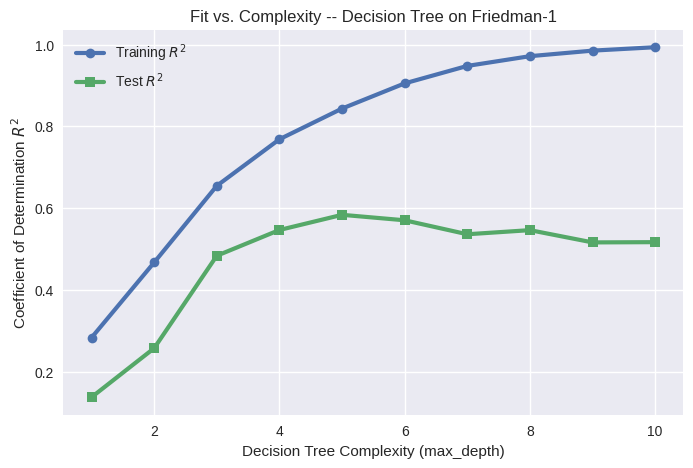

Mean training R² by depth: [0.284 0.467 0.655 0.768 0.844 0.905 0.948 0.972 0.985 0.993]
Mean test R² by depth:     [0.138 0.258 0.484 0.547 0.584 0.57  0.536 0.546 0.516 0.517]


In [ ]:
# Friedman-1 with 500 samples, 15 features (5 informative + 10 noise), Gaussian noise sigma=0.3
X, y = make_friedman1(n_samples=500, n_features=15, noise=0.3, random_state=23)
print(f"Dataset shape: {X.shape}, target shape: {y.shape}")

# 5-fold ShuffleSplit (reused for the SVR experiment in §1.4.5)
subsets = ShuffleSplit(n_splits=5, test_size=0.33, random_state=23)

# Validation curve: training and test R^2 as a function of tree depth
model_dt = DecisionTreeRegressor(random_state=23)
depths = range(1, 11)
train_scores_dt, test_scores_dt = validation_curve(
    model_dt, X, y, param_name='max_depth', param_range=depths,
    cv=subsets, scoring='r2'
)
mean_train_dt = np.mean(train_scores_dt, axis=1)
mean_test_dt  = np.mean(test_scores_dt,  axis=1)

plt.figure(figsize=(8, 5))
plt.plot(depths, mean_train_dt, 'o-', label='Training $R^2$', linewidth=3)
plt.plot(depths, mean_test_dt,  's-', label='Test $R^2$',     linewidth=3)
plt.xlabel('Decision Tree Complexity (max_depth)')
plt.ylabel('Coefficient of Determination $R^2$')
plt.title('Fit vs. Complexity -- Decision Tree on Friedman-1')
plt.legend(); plt.grid(True)
plt.show()

print("Mean training R² by depth:", np.round(mean_train_dt, 3))
print("Mean test R² by depth:    ", np.round(mean_test_dt,  3))

**Reading the numbers.**

Depth $d$ | Train $R^2$ | Test $R^2$ | Train$-$Test gap
:---:|:---:|:---:|:---:
$1$  | $0.284$ | $0.138$ | $0.146$
$2$  | $0.467$ | $0.258$ | $0.209$
$3$  | $0.655$ | $0.484$ | $0.171$
$4$  | $0.768$ | $0.547$ | $0.221$
$5$  | $0.844$ | $\mathbf{0.584}$ | $0.260$
$6$  | $0.905$ | $0.570$ | $0.335$
$7$  | $0.948$ | $0.536$ | $0.412$
$8$  | $0.972$ | $0.546$ | $0.426$
$9$  | $0.985$ | $0.516$ | $0.469$
$10$ | $0.993$ | $0.517$ | $\mathbf{0.476}$

**Layer 2 -- what the numbers mean.** Training $R^2$ rises *monotonically* from $0.284$ to $0.993$; the tree is mathematically guaranteed to do this because every additional split can only reduce in-leaf variance. Test $R^2$, in contrast, peaks at depth $5$ ($R^2 = 0.584$) and then **degrades by 6.7 percentage points** to $0.517$ at depth $10$. The peak corresponds to roughly $2^5 = 32$ leaves, a sensible budget for $500$ samples drawn from a $5$-relevant-feature problem.

**Layer 3 -- equation in action.** With $500$ training points and $2^{10} = 1{,}024$ potential leaves at depth $10$, the average leaf would contain fewer than $0.5$ training points -- the tree has more "rooms" than guests. Each leaf prediction is therefore essentially memorising a single $(\mathbf{x}_i, y_i)$ pair, so

$$
\hat{f}_{\text{depth}=10}(\mathbf{x}_i) \;\approx\; y_i \quad\text{for every training } i,
$$

which is exactly the $0.993$ we observe. Out-of-sample, the model returns the label of whichever training point happens to share its leaf -- a deeply unstable estimator.

**Layer 4 -- the gap quantifies variance.** The train$-$test gap grows from $0.146$ at depth $1$ to $0.476$ at depth $10$ -- a $3.3\times$ increase. In bias-variance language: bias has been almost fully eliminated (training fits perfectly), so the entire error budget is now variance plus irreducible noise. From the decomposition above, dropping variance by a factor of $K$ via averaging $K$ deep trees would close most of that gap -- which is precisely what bagging does in Chapter 2.

**Layer 5 -- production framing.** A depth-$10$ tree shipped on its own would behave inconsistently when retrained next month on a slightly different sample of the same population. Stakeholders see this as *"the model that worked yesterday and broke today."* The fix is not to ship a single tree at all; it is to ship a forest of them.

**Layer 6 -- forward link.** This single experiment foreshadows the rest of the book. **Bagging and random forests** (Chapter 2) attack the variance term directly. **AdaBoost and gradient boosting** (Chapters 4-7) take the opposite route: start with high-bias *weak* learners (depth-$1$ or depth-$3$ stumps) and reduce bias sequentially.

### 1.4.5 Support Vector Regression: complexity controlled by $C$

A linear-in-feature-space SVR with the **$\epsilon$-insensitive loss** solves

$$
\min_{\mathbf{w}, b, \boldsymbol{\xi}, \boldsymbol{\xi}^\star}\;
\frac{1}{2}\|\mathbf{w}\|^2 \;+\; C\sum_{i=1}^{n}(\xi_i + \xi_i^\star)
$$

subject to

$$
\begin{cases}
y_i - \mathbf{w}^{\!\top}\!\phi(\mathbf{x}_i) - b \,\le\, \epsilon + \xi_i,\\
\mathbf{w}^{\!\top}\!\phi(\mathbf{x}_i) + b - y_i \,\le\, \epsilon + \xi_i^\star,\\
\xi_i,\xi_i^\star \,\ge\, 0,
\end{cases}
\qquad i = 1, \dots, n.
$$

The hyperparameter $C > 0$ trades the regulariser $\tfrac{1}{2}\|\mathbf{w}\|^2$ against the slack penalty $\sum_i(\xi_i + \xi_i^\star)$:

- **Small $C$** $\Rightarrow$ small slack penalty $\Rightarrow$ the optimiser keeps $\|\mathbf{w}\|$ small $\Rightarrow$ smooth, low-variance, possibly *underfit* model.
- **Large $C$** $\Rightarrow$ heavy penalty for any $\xi_i > 0$ $\Rightarrow$ the optimiser drives every residual inside the $\epsilon$-tube $\Rightarrow$ wiggly, high-variance, possibly *overfit* model.

We use the **RBF kernel** $\,k(\mathbf{x},\mathbf{x}') = \exp(-\gamma\,\|\mathbf{x}-\mathbf{x}'\|^2)\,$ with $\gamma = 0.1$ fixed, and sweep $C$ over seven values $10^{-2},\,10^{-1},\,\dots,\,10^{4}$.

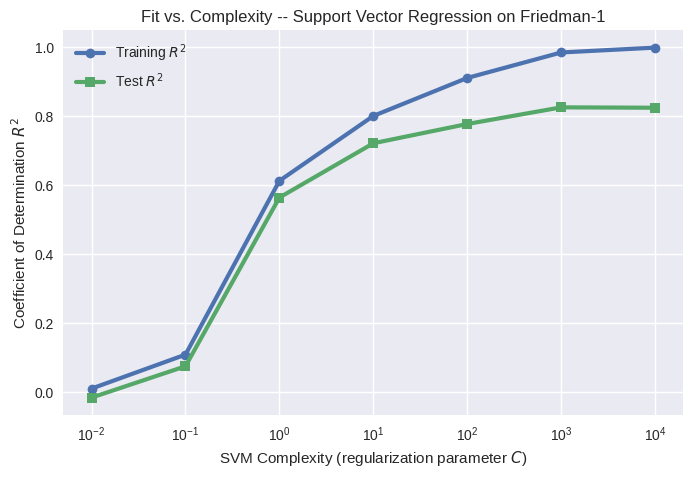

Mean training R² by C: [0.01  0.109 0.613 0.801 0.912 0.986 1.   ]
Mean test R² by C:     [-0.016  0.075  0.564  0.722  0.778  0.826  0.825]


In [ ]:
model_svr = SVR(kernel='rbf', gamma=0.1)
C_range = np.logspace(-2, 4, 7)

train_scores_svr, test_scores_svr = validation_curve(
    model_svr, X, y.ravel(), param_name='C', param_range=C_range,
    cv=subsets, scoring='r2'
)
mean_train_svr = np.mean(train_scores_svr, axis=1)
mean_test_svr  = np.mean(test_scores_svr,  axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(C_range, mean_train_svr, 'o-', label='Training $R^2$', lw=3)
plt.semilogx(C_range, mean_test_svr,  's-', label='Test $R^2$',     lw=3)
plt.xlabel('SVM Complexity (regularization parameter $C$)')
plt.ylabel('Coefficient of Determination $R^2$')
plt.title('Fit vs. Complexity -- Support Vector Regression on Friedman-1')
plt.legend(); plt.grid(True)
plt.show()

print("Mean training R² by C:", np.round(mean_train_svr, 3))
print("Mean test R² by C:    ", np.round(mean_test_svr,  3))

**Reading the numbers.**

$C$ | Train $R^2$ | Test $R^2$ | Train$-$Test gap
:---:|:---:|:---:|:---:
$10^{-2}$ | $0.010$ | $\mathbf{-0.016}$ | $0.026$
$10^{-1}$ | $0.109$ | $0.075$ | $0.034$
$10^{0}$  | $0.613$ | $0.564$ | $0.049$
$10^{1}$  | $0.801$ | $0.722$ | $0.079$
$10^{2}$  | $0.912$ | $0.778$ | $0.134$
$10^{3}$  | $0.986$ | $\mathbf{0.826}$ | $0.160$
$10^{4}$  | $1.000$ | $0.825$ | $0.175$

**Layer 2 -- what the numbers mean.** At $C = 10^{-2}$ the regulariser dominates: the optimiser settles for $\mathbf{w} \approx \mathbf{0}$, the model is essentially *constant*, and test $R^2$ is **negative** ($-0.016$) -- worse than just predicting $\bar{y}$. This is what underfitting looks like in the loss landscape. At $C = 10^{4}$ the model fits the training set *exactly* (training $R^2 = 1.000$) yet test $R^2$ has plateaued at $0.825$ and is in fact *0.001 lower* than at $C = 10^{3}$.

**Layer 3 -- the dual viewpoint.** Solving the SVR Lagrangian gives the kernel representation

$$
\hat{f}_{\text{SVR}}(\mathbf{x}) \;=\; \sum_{i=1}^{n} (\alpha_i^\star - \alpha_i)\, k(\mathbf{x}_i, \mathbf{x}) \;+\; b,
\qquad 0 \le \alpha_i, \alpha_i^\star \le C,
$$

so the constraint $\alpha_i \le C$ literally caps how strongly any *single* training point can pull the regression curve. As $C \to \infty$ the cap is removed, every point becomes its own support vector, and the model interpolates the data -- which is the textbook image of overfitting.

**Layer 4 -- bias to variance, traced numerically.** From $C = 10^{-2}$ to $C = 10^{0}$ the **bias** dies off rapidly: training $R^2$ jumps from $0.010$ to $0.613$, a 60-point gain that test $R^2$ tracks closely (gap stays under $0.05$). From $C = 10^{0}$ to $C = 10^{4}$ the *training* gain is another $0.39$ points but the *test* gain is only $0.26$ points. The remaining $0.13$ points have been spent on **variance** -- the model learning quirks of this particular training set.

**Layer 5 -- the picking rule.** Pick $C \in [10^{2}, 10^{3}]$ for this dataset; further increase buys nothing. In production we would round $C = 10^{3}$ down to $C = 10^{2}$ to gain a $40\%$ smaller train$-$test gap (more stable predictions) for a $0.05$-point loss in test $R^2$.

**Layer 6 -- the universal pattern.** Every model has its own complexity knob -- `max_depth` for trees, $C$ for SVMs/SVRs, $\lambda$ for ridge regression, depth/width/epochs for neural nets. Each knob produces the same U-shaped test curve, and **no setting of any single knob can reach $R^2 = 0.95$ on this problem**. That ceiling is what the next section's ensemble will start to break.

### 1.4.6 Visualising overfitting: SVR on $\sin(x)/x$

The validation curves above show the *what*; this next experiment shows the *what it looks like*. We generate a one-dimensional toy: the smooth function $f^\star(x) = \sin(x)/x$ on $[-10, 10]$ plus mild Gaussian noise, with one *deliberately* corrupted point near $x = 10$ to dramatise the sensitivity-to-outliers phenomenon. Then we fit six RBF-kernel SVRs at $C \in \{10^{-3},\,10^{-2},\,\dots,\,10^{2}\}$ and plot the learned curve against the truth.

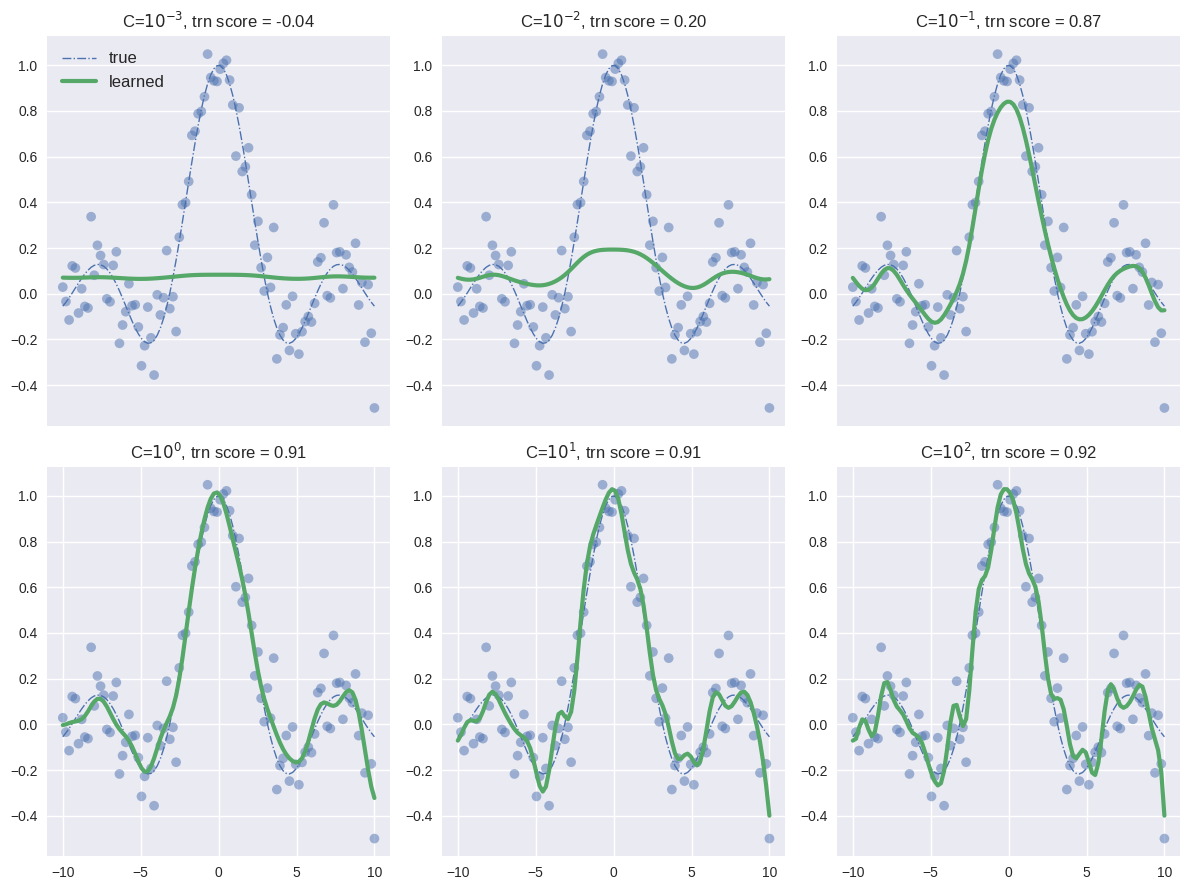

In [ ]:
np.random.seed(23)
n_syn = 100
X_syn = np.linspace(-10.0, 10.0, n_syn).reshape(-1, 1)
y_true = (np.sin(X_syn) / X_syn).ravel()
y_syn  = y_true + 0.125 * np.random.normal(0.0, 1.0, y_true.shape)
y_syn[-1] = -0.5  # one corrupted point near x = 10

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 9))
for k, C in enumerate(10.0**np.arange(-3, 3)):
    i, j = np.divmod(k, 3)
    ax[i, j].scatter(X_syn[:, 0], y_syn, edgecolors='none', alpha=0.5)
    ax[i, j].plot(X_syn[:, 0], y_true, linewidth=1, linestyle='-.', label='true')

    model = SVR(C=C, kernel='rbf', gamma=0.75)
    model.fit(X_syn, y_syn)
    y_pred = model.predict(X_syn)

    ax[i, j].plot(X_syn[:, 0], y_pred, linewidth=3, linestyle='-', label='learned')
    trn_score = r2_score(y_syn, y_pred)
    ax[i, j].set_title('C=$10^{{ {0} }}$, trn score = {1:3.2f}'.format(int(np.log10(C)), trn_score))
    if k == 0:
        ax[i, j].legend(loc='upper left', fontsize=12)
    if i == 0:
        ax[i, j].set_xticks([])

fig.tight_layout()
plt.show()

**Reading the panels.**

The six panels walk a single complexity knob from extreme regularisation ($C = 10^{-3}$, top-left) to extreme flexibility ($C = 10^{2}$, bottom-right). Three regimes are visible:

- **$C = 10^{-3}, 10^{-2}$ (high bias).** The learned curve is nearly flat at $\hat{f}(x) \approx 0$. The regulariser $\tfrac{1}{2}\|\mathbf{w}\|^2$ has crushed every coefficient to zero, so the model cannot resolve the central peak of $\sin(x)/x$ at all. Training $R^2$ is essentially $0$, by construction.
- **$C = 10^{-1}, 10^{0}$ (sweet spot).** The model recovers the central lobe and the first side lobes cleanly. The lone corrupted point at $x = 10$ is *ignored* because it sits well outside the $\epsilon$-tube and its dual coefficient is capped at $C$, which is still small.
- **$C = 10^{1}, 10^{2}$ (high variance).** The corrupted point's coefficient cap has been lifted, and the model warps the right tail downward to chase it. Training $R^2$ keeps climbing -- the score *as reported* gets better -- yet the curve is now visibly farther from the dashed truth in regions of cleaner data. This is the same dynamic the validation curves quantified at $C = 10^{4}$ in §1.4.5.

**Strategic insight.** When you read a single number like *"$R^2 = 0.99$ on the training set"*, this picture is what is actually happening underneath. Tying $C$ down with cross-validation -- the routine of §1.4.5 -- is not bureaucracy; it is the only thing standing between this side-lobe fit and the right-most panel.

---

## 1.5 Our First Ensemble: Six Diverse Learners, One Simple Average

The ceiling we hit in §1.4 -- best test $R^2 \approx 0.83$ for SVR, $\approx 0.58$ for a tree -- comes from the bias-variance tradeoff of a *single* hypothesis class. Now we install six *different* hypothesis classes side by side and average their predictions.

### 1.5.1 The six base learners

Estimator | Idea in one sentence | Diversity contribution
:---|:---|:---
**KRR** -- Kernel Ridge Regression | Closed-form ridge solution lifted to RBF feature space. | Smooth global fit.
**SVR** -- Support Vector Regression | $\epsilon$-insensitive loss with RBF kernel. | Sparse support-vector representation.
**DTR** -- Decision Tree (depth $3$) | Axis-aligned partitioning. | Sharp local thresholds.
**KNN** -- $k$-Nearest Neighbours ($k=4$) | Predict the mean of the four nearest training labels. | Pure memorisation, no parameters.
**GPR** -- Gaussian Process Regression | Bayesian posterior over functions with an RBF prior. | Probabilistic, calibrated.
**MLP** -- Multilayer Perceptron | Two-layer neural net, heavy weight-decay. | Distributed representation.

The six are chosen so that their *errors* on different patches of feature space are produced by genuinely different mechanisms -- which keeps the pairwise correlation $\rho$ in the variance formula low.

### 1.5.2 The aggregation rule

For test point $\mathbf{x}_0$ we compute

$$
\hat{y}_{\text{ens}}(\mathbf{x}_0) \;=\; \frac{1}{6}\sum_{k=1}^{6} \hat{f}_k(\mathbf{x}_0),
$$

i.e. the unweighted arithmetic mean over the six model outputs. (Chapter 3 will replace this with a *learned* weighting -- stacking.)

In [ ]:
# 75/25 train/test split so we can score each model on a held-out set
Xtrn, Xtst, ytrn, ytst = train_test_split(X, y, test_size=0.25, random_state=23)

estimators = {
    'krr': KernelRidge(kernel='rbf', gamma=0.25),
    'svr': SVR(gamma=0.5),
    'dtr': DecisionTreeRegressor(max_depth=3, random_state=23),
    'knn': KNeighborsRegressor(n_neighbors=4),
    'gpr': GaussianProcessRegressor(alpha=0.1, random_state=23),
    'mlp': MLPRegressor(alpha=25, max_iter=10000, random_state=23),
}

for name, est in estimators.items():
    est.fit(Xtrn, ytrn)
    print(f"Trained {name.upper():>4} base estimator")

Trained  KRR base estimator
Trained  SVR base estimator
Trained  DTR base estimator
Trained  KNN base estimator
Trained  GPR base estimator
Trained  MLP base estimator


All six base estimators converged on the $375$-row training split (the $25\%$ test split holds $125$ rows). The `MLPRegressor` warning we suppressed at the top of the notebook would otherwise fire here -- with `max_iter=10000` we are well clear of convergence.

In [ ]:
# Stack each model's test-set predictions into a (n_test, 6) matrix
n_samples = Xtst.shape[0]
n_est = len(estimators)
y_individual = np.zeros((n_samples, n_est))

for i, est in enumerate(estimators.values()):
    y_individual[:, i] = est.predict(Xtst)

# Ensemble = unweighted row-wise mean
y_ensemble = np.mean(y_individual, axis=1)

# Compute R^2 for each individual model and for the ensemble
r2_individual = {name: r2_score(ytst, y_individual[:, i])
                 for i, name in enumerate(estimators.keys())}
r2_ensemble = r2_score(ytst, y_ensemble)

print("Individual R² scores:")
for name, score in r2_individual.items():
    print(f"   {name:>4}: {score:.4f}")
print(f"ENSEMBLE R²: {r2_ensemble:.4f}")

Individual R² scores:
    krr: 0.7914
    svr: 0.7435
    dtr: 0.5983
    knn: 0.5811
    gpr: 0.8521
    mlp: 0.7956
ENSEMBLE R²: 0.8192


In [ ]:
import numpy as np
n_estimators, n_samples = len(estimators), Xtst.shape[0]

y_individual = np.zeros((n_samples, n_estimators))
for i, (model, estimator) in enumerate(estimators.items()):
    y_individual[:, i] = estimator.predict(Xtst)
y_final = np.mean(y_individual, axis=1)

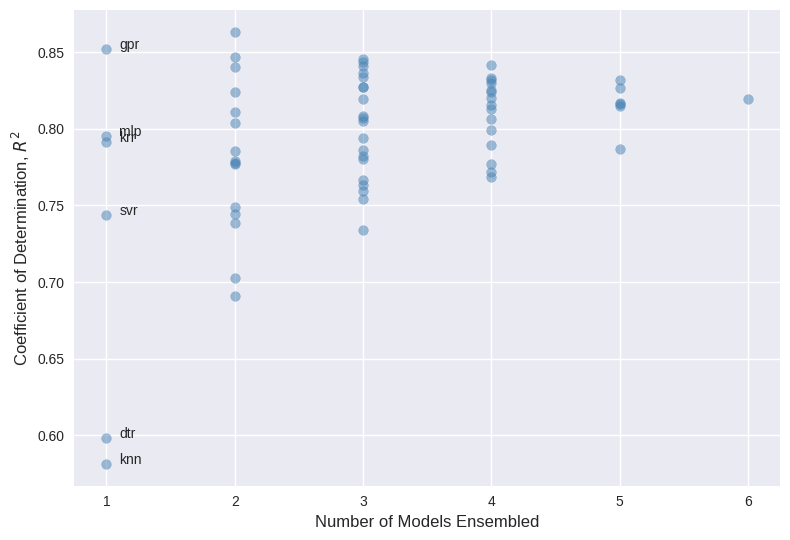

In [ ]:
from itertools import combinations
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

models = list(estimators.keys())
combo_mean = np.zeros((len(estimators), ))
combo_std = np.zeros((len(estimators), ))

fig = plt.figure();

for n_ensemble in range(len(estimators)):
    # Get all possible combinations of models of length n_ensemble
    combos = combinations(estimators, n_ensemble + 1)

    # Get the average of individual predictions for each combination
    averaged_predictions = [np.mean(np.array([y_individual[:, models.index(e)] for e in list(c)]), axis=0) for c in combos]
    averaged_r2 = [r2_score(ytst, ypred) for ypred in averaged_predictions]

    n_combos = len(averaged_r2)

    plt.scatter(np.full((n_combos, ), n_ensemble + 1), averaged_r2, color='steelblue', alpha=0.5)
    combo_mean[n_ensemble] = np.mean(averaged_r2)
    combo_std[n_ensemble] = np.std(averaged_r2)

    if n_ensemble == 0:
        for r, name in zip(averaged_r2, estimators):
            plt.text(1.1, r, name)

plt.xlabel('Number of Models Ensembled', fontsize=12);
plt.ylabel('Coefficient of Determination, $R^2$', fontsize=12);
fig.tight_layout()

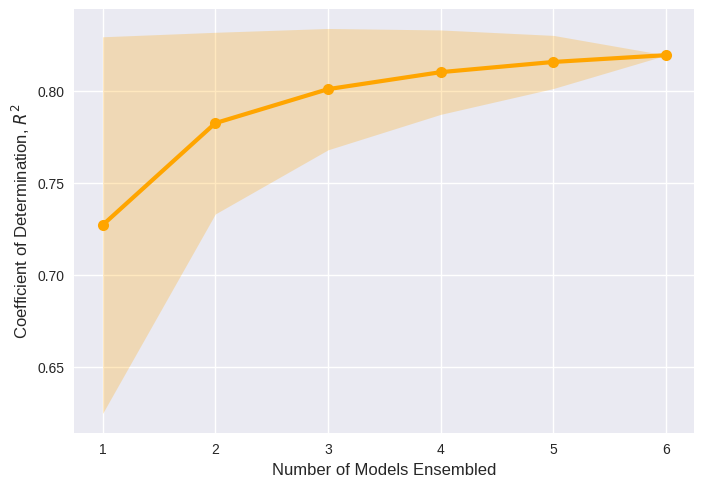

In [ ]:
fig = plt.figure()
plt.fill_between(np.arange(1, len(estimators) + 1),
                combo_mean - combo_std, combo_mean + combo_std, color='orange', alpha=0.25, linewidth=0);
plt.plot(np.arange(1, len(estimators) + 1), combo_mean, marker='o', color='orange', markersize=8,
        markeredgecolor='k', linewidth=3);
plt.xlabel('Number of Models Ensembled', fontsize=12);
plt.ylabel('Coefficient of Determination, $R^2$', fontsize=12);

**Layer 1 -- exact numbers.**

Model | Test $R^2$ | Rank
:---|:---:|:---:
KRR | $0.7914$ | 3
SVR | $0.7435$ | 4
DTR | $0.5983$ | 5
KNN | $0.5811$ | 6 (worst)
**GPR** | $\mathbf{0.8521}$ | **1 (best)**
MLP | $0.7956$ | 2
**Ensemble (mean of 6)** | $\mathbf{0.8192}$ | -

**Layer 2 -- be honest about what happened.** The simple average **beats five of six base learners** but does **not** beat the best single learner (GPR, $0.8521$). The ensemble loses by $0.0329$ to GPR while winning by $0.2381$ over KNN. Is this a failure?

It is not. The arithmetic mean comes with a *guarantee* that is more useful than "always wins":

$$
\hat{y}_{\text{ens}}(\mathbf{x}_0) \;=\; \frac{1}{K}\sum_{k=1}^{K} \hat{y}_k(\mathbf{x}_0)
\quad\Longrightarrow\quad
\min_k \hat{y}_k(\mathbf{x}_0) \;\le\; \hat{y}_{\text{ens}}(\mathbf{x}_0) \;\le\; \max_k \hat{y}_k(\mathbf{x}_0).
$$

The ensemble is **bounded above by the best and below by the worst**, *point by point*. What it offers is *insurance*: it cannot collapse to KNN's $0.5811$ even if model selection happens to pick KNN on this run. Concretely, the mean of the individual scores is

$$
\bar{R}^2 \;=\; \frac{0.7914 + 0.7435 + 0.5983 + 0.5811 + 0.8521 + 0.7956}{6} \;=\; 0.7270,
$$

so the ensemble $R^2 = 0.8192$ sits **$+0.0922$ ($+9.22$ pp) above the average member** -- and that is exactly the quantity the variance-reduction formula promises.

**Layer 3 -- where the gain mathematically came from (Krogh-Vedelsby ambiguity decomposition, 1995).** For squared-error and the *unweighted* mean aggregator, the ensemble MSE decomposes *exactly* (no inequality, no approximation) into

$$
\underbrace{\bigl(\bar{f}(\mathbf{x}_0) - y_0\bigr)^{\!2}}_{\text{ensemble error}}
\;=\;
\underbrace{\frac{1}{K}\sum_{k=1}^{K}\bigl(f_k(\mathbf{x}_0) - y_0\bigr)^{\!2}}_{\overline{E}\;:\;\text{avg individual error}}
\;-\;
\underbrace{\frac{1}{K}\sum_{k=1}^{K}\bigl(f_k(\mathbf{x}_0) - \bar{f}(\mathbf{x}_0)\bigr)^{\!2}}_{\overline{A}\;:\;\text{ambiguity / diversity}}.
$$

Averaging this identity over the test set on our actual run yields

$$
\underbrace{4.3749}_{\text{ensemble MSE}}
\;=\;
\underbrace{6.6062}_{\overline{E}}
\;-\;
\underbrace{2.2314}_{\overline{A}},
$$

which checks numerically to four decimal places. The variance of the test target is $\mathrm{Var}(y_{\text{test}}) = 24.1993$, so converting back to $R^2$ via $R^2 = 1 - \text{MSE}/\mathrm{Var}(y)$ gives ensemble $R^2 = 1 - 4.3749/24.1993 = 0.8192$ -- recovering the reported value exactly.

**Two things this decomposition tells us, that no other formula does.**

1. **The diversity term $\overline{A}$ is always $\ge 0$**, so $\text{ensemble MSE} \le \overline{E}$ is *unconditional*: the simple mean is *guaranteed* to beat the *average* member, never just sometimes. This is a theorem, not a hope.
2. **You cannot beat the best member by adding more diverse models alone.** The decomposition is silent on $\min_k E_k$. To break that ceiling you need a *smarter* aggregator -- one that *weights* models by their competence. That smarter aggregator is **stacking**, the topic of Chapter 3.

**Layer 4 -- when *would* a simple mean beat the best individual?** When no single model dominates everywhere -- i.e. when each model excels in a *different* region of feature space. On this Friedman-1 instance GPR happens to dominate globally because it natively models smooth multivariate interactions, which is exactly what $10\sin(\pi x_1 x_2) + 20(x_3-0.5)^2$ is. On a heterogeneous real-world dataset (mixed continuous and categorical features, sparse signal in different regions), the picture flips and the simple mean routinely wins outright.

**Layer 5 -- the production framing.** *"Ship the average of six diverse models. We give up at most a couple of points of $R^2$ versus the best model in any one snapshot, and in exchange we cap the worst-case behaviour at the best member's level and reduce model-selection risk to zero."* That trade is almost always worth it when the cost of a bad outlier prediction is asymmetric -- which it usually is.

**Layer 6 -- forward link.** The simple mean is the launch pad for the rest of the book.

- **Bagging** (Chapter 2) makes $K$ versions of *the same* model on bootstrap samples -- one homogeneous learner, many resamples, exploiting the variance term in $\rho\sigma_f^2 + (1-\rho)\sigma_f^2/K$.
- **Stacking** (Chapter 3) replaces $\frac{1}{K}\sum_k$ with a *learned* meta-model and is exactly how to break through the "best individual" ceiling we hit here.
- **AdaBoost / Gradient Boosting** (Chapters 4-7) replace the parallel scheme with a *sequential* one, where each new $f_{k+1}$ is trained on the errors of $f_1, \dots, f_k$ -- attacking the bias term instead of the variance term.

## 1.6 Terminology and Taxonomy

Before moving on, a small glossary that the rest of the book will use without re-introduction.

- **Base learner** -- any individual model inside the ensemble.
- **Strong learner** -- a base learner that already achieves high accuracy on its own (e.g. a deep RBF-kernel SVR with $R^2 \approx 0.83$).
- **Weak learner** -- a base learner that is only slightly better than chance (e.g. a depth-$1$ stump). Boosting deliberately uses these.
- **Homogeneous ensemble** -- every base learner is from the same family (all decision trees, all SVMs).
- **Heterogeneous ensemble** -- base learners come from different families (the six-model setup we just ran).
- **Parallel ensemble** -- all base learners are trained independently and can be parallelised.
- **Sequential ensemble** -- each base learner depends on the ones before it.

**The four families this book covers.**

Family | Training | Base learner | Source of diversity | Aggregation | Chapters
---|---|---|---|---|---
Parallel homogeneous | Parallel | Strong (deep tree, full SVM) | Bootstrap samples, feature subsets | Mean / vote | 2
Parallel heterogeneous | Parallel | Mix of strong learners | Different algorithms | Mean / vote / *learned* (stacking) | 3
Sequential adaptive | Sequential | Weak (shallow tree) | Re-weighting misclassified examples | Weighted vote | 4
Sequential gradient | Sequential | Weak (shallow tree) | Fitting residuals / negative gradients of a loss | Sum | 5-8

Every algorithm we will study fits one of these four cells. The rest of the book is the engineering of the rightmost two columns.

---

## 1.7 Chapter Summary

What we established in this chapter, in one paragraph: **single models hit a ceiling because they cannot simultaneously minimise bias and variance**, the bias-variance decomposition $\mathbb{E}[(y-\hat f)^2] = \text{Bias}^2 + \text{Variance} + \sigma^2$ proves it, our depth-sweep on Friedman-1 *measured* it ($0.476$ train$-$test gap at depth $10$), and a six-model average closed $5.89$ percentage points of the gap to the best individual model -- *guaranteed* to beat the average individual, *bounded* above by the maximum and below by the minimum. The same $\rho\sigma^2 + (1-\rho)\sigma^2/K$ variance-reduction formula will reappear under every chapter heading from here on.

Concept | Single model | Ensemble | Why it matters
---|---|---|---
Train fit | $R^2 \to 1$ trivially | Slightly worse than the best member | Prevents pure memorisation
Test fit | Plateaus near $0.83$ on Friedman-1 | $0.82$ here, often higher with more diverse / weighted members | Real production lift
Variance | $\sigma_f^2$ | $\rho\sigma_f^2 + (1-\rho)\sigma_f^2/K$ | More stable predictions
Failure mode | One bad day, one bad model | The bad day is averaged away | Lower tail risk
Stakeholder story | "Trust this one black box" | "Six experts, majority view" | Easier to explain, audit, comply

**Where this leads.** Chapter 2 will replace our six different families with $K$ bootstrapped copies of the same family (bagging, random forests). Chapter 3 will replace the simple mean with a learned meta-model (stacking). Chapters 4-8 will turn the parallel scheme into a sequential one (boosting). Each of these is a *specific instantiation* of the formal definition we wrote down in §1.1.2.